In [1]:
import numpy as np
import pandas as pd

# Load from local file
df = pd.read_csv('D:/Summer_intern/hindi_text_sentiment.csv')

# Display the first few rows
print(df.head())


                                                 OCR Sentiment
0  Ba8@ DaNn G@rainiD IR T३ PDBB WRHE W PRD BCEN ...   Neutral
1  Nari nari mat kar pagle, Nari he nark ka dwar....  Negative
2  Kitni push ops maarsakte ho dafly? 5 aur agar ...  Positive
3  अब इसमें मेरी कहां गलती है बताओ.. तरबूज़ वाली क...  Negative
4  "KUDI MENU KEHNDl... 'MENU JUTI LA DE SONIYE.....  Negative


In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the dataset
df = pd.read_csv('D:/Summer_intern/hindi_text_sentiment.csv')

# Strip any unwanted whitespace from column names
df.columns = df.columns.str.strip()

# Show actual column names (for confirmation)
print("Columns:", df.columns.tolist())  # Should show ['OCR', 'Sentiment']

# Drop rows with missing text or sentiment
df = df.dropna(subset=['OCR', 'Sentiment'])

# Rename columns for consistency
df.rename(columns={'OCR': 'text', 'Sentiment': 'label'}, inplace=True)

# Convert all text to string
df['text'] = df['text'].astype(str)

# Encode labels (e.g., Positive, Negative, Neutral → 0, 1, 2)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Optional: Show mapping
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.10, random_state=42
)

# Tokenize text
vocab_size = 10000
max_length = 50

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')


Columns: ['OCR', 'Sentiment']
Label Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# RNN model

embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_length,)),
    SimpleRNN(64),
    Dense(3, activation='softmax')  # for 3-class sentiment
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train
history = model.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 50, 64)              │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 648,451 (2.47 MB)

 Trainable params: 648,451 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4027 - loss: 1.0949 - val_accuracy: 0.4853 - val_loss: 1.0314
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6164 - loss: 0.8705 - val_accuracy: 0.4265 - val_loss: 1.1166
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9489 - loss: 0.3138 - val_accuracy: 0.3775 - val_loss: 1.3939
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9961 - loss: 0.0705 - val_accuracy: 0.3578 - val_loss: 1.6792
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9996 - loss: 0.0363 - val_accuracy: 0.3775 - val_loss: 1.9288
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0156 - val_accuracy: 0.3922 - val_loss: 1.9164
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.3529 - val_loss: 1.9960
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.3725 - v

In [16]:
#  test set
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4080 - loss: 2.2670

Test Accuracy: 0.4211
Test Loss: 2.1821


In [20]:
y_test

787     2
906     2
414     1
469     0
749     2
       ..
364     0
1020    0
573     2
674     1
1009    2
Name: label, Length: 114, dtype: int32

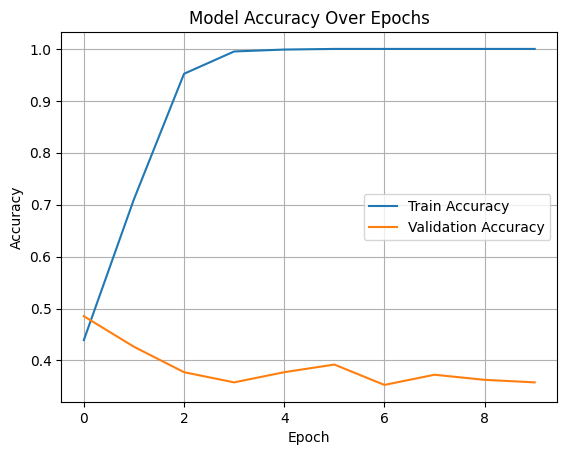

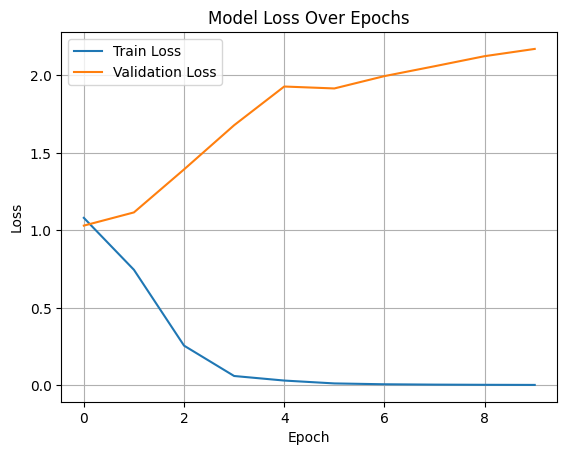

In [17]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
